In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# Check TensorFlow version and available GPU devices

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("GPU is available:")
    for gpu in gpus:
        print(gpu)
else:
    print("GPU is not available. Please enable GPU runtime in Colab.")


TensorFlow version: 2.20.0
GPU is available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
# Upload dataset file

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/IMDB Dataset/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Check dataset information
print(df.shape)

df.info()

df["sentiment"].value_counts()

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [8]:
# Convert text labels into numerical labels

# positive -> 1
# negative -> 0

encoder = LabelEncoder()

df["sentiment"] = encoder.fit_transform(df["sentiment"])

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


Dataset Shape:
(50000, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB

Sentiment Distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Review Length Statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


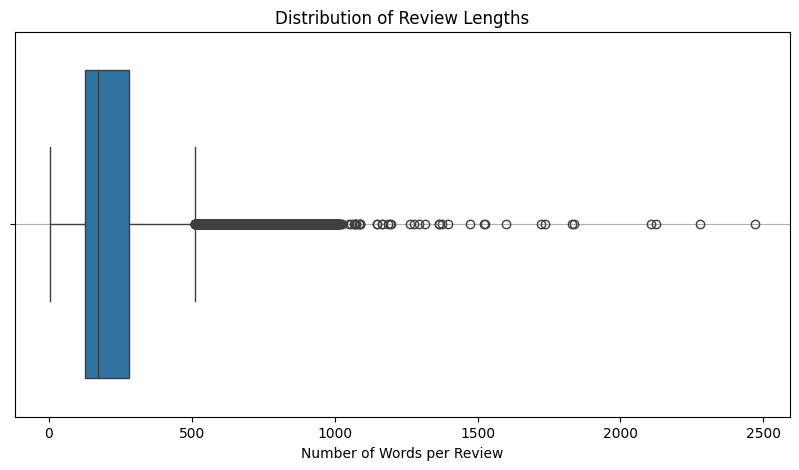

In [9]:
# ==========================================
# Dataset Overview and Statistical Analysis
# ==========================================

import seaborn as sns


# Display basic dataset information

print("Dataset Shape:")
print(df.shape)


print("\nDataset Information:")
df.info()


# Display class distribution

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


# Create a new column containing review length
# The value represents the number of words in each review
df["review_length"] = df["review"].apply(lambda x: len(x.split()))


# Display statistical information about review lengths
print("\nReview Length Statistics:")
print(df["review_length"].describe())


# ==========================================
# Box Plot of Review Lengths
# ==========================================
plt.figure(figsize=(10,5))
sns.boxplot(x=df["review_length"])
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words per Review")
plt.grid(axis="y")
plt.show()


Dataset Shape:
(50000, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review         50000 non-null  object
 1   sentiment      50000 non-null  int64 
 2   review_length  50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB

Sentiment Distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Review Length Statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


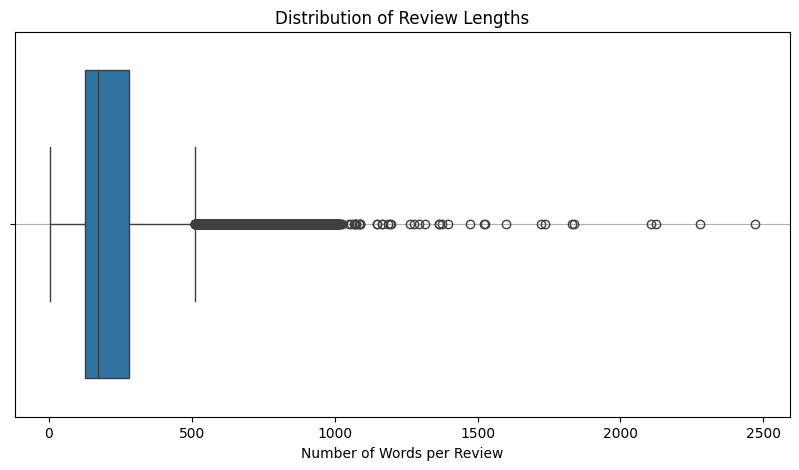

In [10]:
# ==========================================
# Dataset Overview and Statistical Analysis
# ==========================================

import seaborn as sns


# Display basic dataset information

print("Dataset Shape:")
print(df.shape)


print("\nDataset Information:")
df.info()


# Display class distribution

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


# Create a new column containing review length
# The value represents the number of words in each review
df["review_length"] = df["review"].apply(lambda x: len(x.split()))


# Display statistical information about review lengths
print("\nReview Length Statistics:")
print(df["review_length"].describe())


# ==========================================
# Box Plot of Review Lengths
# ==========================================
plt.figure(figsize=(10,5))
sns.boxplot(x=df["review_length"])
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words per Review")
plt.grid(axis="y")
plt.show()


In [11]:
# Separate input text and target labels

X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

In [12]:
# Create tokenizer and convert text into sequences
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[0][:20])

[230, 1, 120, 7961, 13, 27, 4, 57, 527, 1058, 98, 50, 10, 13, 120, 10, 13, 2122, 42, 91]


In [13]:
# Apply padding to make all sequences the same length
MAX_LENGTH = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)

(45000, 200)


In [14]:
# Create LSTM classification model
model = Sequential()

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    )
)

model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
# Train the model with callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_lstm_sentiment_model.keras",
        save_best_only=True
    )
]

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5531 - loss: 0.6858 - val_accuracy: 0.6024 - val_loss: 0.6672
Epoch 2/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5946 - loss: 0.6610 - val_accuracy: 0.6110 - val_loss: 0.6318
Epoch 3/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6139 - loss: 0.6621 - val_accuracy: 0.6034 - val_loss: 0.6669
Epoch 4/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5863 - loss: 0.6561 - val_accuracy: 0.5828 - val_loss: 0.6502


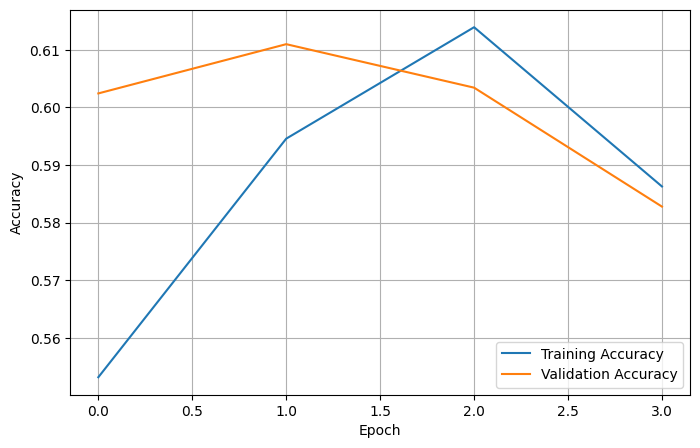

In [17]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.grid()
plt.show()

In [18]:
# Evaluate final model

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6024 - loss: 0.6369
Test Accuracy: 0.602400004863739


In [19]:
# Generate predictions and evaluation report
y_probability = model.predict(X_test_pad)

y_prediction = (y_probability > 0.5).astype("int32")

print(
    classification_report(
        y_test,
        y_prediction
    )
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.80      0.27      0.41      2500
           1       0.56      0.93      0.70      2500

    accuracy                           0.60      5000
   macro avg       0.68      0.60      0.55      5000
weighted avg       0.68      0.60      0.55      5000



In [20]:
# Display confusion matrix

cm = confusion_matrix(
    y_test,
    y_prediction
)

print(cm)


[[ 686 1814]
 [ 174 2326]]


In [21]:
# Save final model

model.save("/content/drive/MyDrive/IMDB Dataset/LSTM_IMDB_Sentiment_Model.keras")

print("Model saved in ""/content/drive/MyDrive/IMDB Dataset"" successfully.")

Model saved in /content/drive/MyDrive/IMDB Dataset successfully.


In [22]:
# Prediction function

def predict_sentiment(review):

    sequence = tokenizer.texts_to_sequences([review])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post"
    )

    probability = model.predict(padded_sequence)[0][0]

    label = "Positive" if probability >= 0.5 else "Negative"

    return label, float(probability)

In [23]:
# Batch testing multiple reviews

reviews = [
    "A masterpiece. One of the best movies I have ever seen.",
    "The worst film I have watched this year.",
    "The movie was okay but not very impressive.",
    "Fantastic performance and amazing direction."
]

for review in reviews:
    result = predict_sentiment(review)
    print("\nReview:")
    print(review)
    print("Prediction:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Review:
A masterpiece. One of the best movies I have ever seen.
Prediction: ('Positive', 0.5137224793434143)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Review:
The worst film I have watched this year.
Prediction: ('Positive', 0.5137224793434143)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Review:
The movie was okay but not very impressive.
Prediction: ('Positive', 0.5137224793434143)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Review:
Fantastic performance and amazing direction.
Prediction: ('Positive', 0.5137224793434143)


In [ ]:

# Display program information
print("====================================")
print(" IMDB Sentiment Analysis System ")
print(" Type 'end' to exit ")
print("====================================")



from tensorflow.keras.models import load_model


# Load the saved trained model from Google Drive
model = load_model("/content/drive/MyDrive/IMDB Dataset/LSTM_IMDB_Sentiment_Model.keras")

# Display model loading status
print("LSTM Sentiment Model loaded successfully.")


# Create an infinite loop to continuously receive user input
while True:

    # Get review text from the user
    user_review = input("\nEnter your movie review: ")


    # Check if the user wants to terminate the program
    if user_review.lower() == "end":

        print("Program terminated.")

        break


    # Convert input text into numerical sequence
    # using the tokenizer trained on IMDB dataset
    sequence = tokenizer.texts_to_sequences(
        [user_review]
    )


    # Apply padding to make the input length equal
    # to the maximum sequence length used during training
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )


    # Perform prediction using the trained LSTM model
    # The output is a probability between 0 and 1
    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]


    # Convert probability value into sentiment label
    # Probability >= 0.5  --> Positive
    # Probability < 0.5   --> Negative

    if probability >= 0.5:

        sentiment = "Positive"

    else:

        sentiment = "Negative"



    # Display prediction result

    print("\nPrediction:", sentiment)


    # Display model confidence percentage

    print(
        "Confidence:",
        round(float(probability) * 100, 2),
        "%"
    )

 IMDB Sentiment Analysis System 
 Type 'end' to exit 
LSTM Sentiment Model loaded successfully.
